# Mesh sensitivity analysis 

2026-09-30

Parameter sweep used with mapFields (interpolated)

| Mesh             | `nr_gap` | `nr_core` | `nz_ann` | `nz_bot` | Cells   |
| ---------------- | -------- | --------- | -------- | -------- | ------- |
| coarse (current) | 20       | 100       | 150      | 30       | 6,600   |
| medium           | 30       | 150       | 225      | 45       | ~14,900 |
| fine             | 45       | 225       | 338      | 68       | ~33,500 |


In [13]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
from IPython.display import Markdown, display
from cfdtools import post
from cfdtools.monitor import find_series, read_dat
from cfdtools.convergence import gci

post.use_style()

study = Path("../cases/mesh_study")
names = ["coarse", "medium", "fine"]
mesh_colors = dict(zip(names, post.SERIES))     # one colour per mesh, same order in every figure

## Read the three cases

In [14]:
data = {}
for name in names:
    case = study / name
    p = post.case_parameters(case)
    k, rho = float(p["wedge_to_full"]), float(p["rho_kg_m3"])
    mesh, _ = post.read_case(case)
    s = find_series(case)
    side_torque = read_dat(s["rotorSideTorque/moment"])
    bottom_torque = read_dat(s["rotorBottomTorque/moment"])
    iterations = read_dat(s["residuals/solverInfo"])["Time"][-1]

    # Radial velocity up the middle of the gap: sign changes mark vortex boundaries
    r_mid = 0.5 * (float(p["Ri"]) + float(p["Ro"]))
    z0, z1 = mesh.bounds[4], mesh.bounds[5]
    dist, ur = post.sample_line(mesh, (r_mid, 0, z0), (r_mid, 0, z1), "U", which="x", n=2000)
    sign_changes = np.count_nonzero(np.diff(np.sign(ur)))

    # Wall shear stress (kinematic in the file: multiply by rho for Pa)
    side, _ = post.read_patch(case, "rotorSide")
    side = side.compute_cell_sizes(length=False, area=True, volume=False)
    tau_side = np.linalg.norm(side.cell_data["wallShearStress"], axis=1) * rho
    area = side.cell_data["Area"]
    z_side = side.cell_centers().points[:, 2]

    bottom, _ = post.read_patch(case, "rotorBottom")      # bottom face and the edge fillet
    tau_bottom = np.linalg.norm(bottom.cell_data["wallShearStress"], axis=1) * rho
    xyz = bottom.cell_centers().points
    r_bottom = np.hypot(xyz[:, 0], xyz[:, 1])

    data[name] = dict(
        cells=mesh.n_cells,
        iterations=iterations,
        T_side=side_torque["total_z"][-1] * k,
        T_bottom=bottom_torque["total_z"][-1] * k,
        ur_max=abs(ur).max(),
        sign_changes=sign_changes,
        tau_mean=(tau_side * area).sum() / area.sum(),
        tau_max=tau_side.max(),
        tau_bottom_max=tau_bottom.max(),
        z_ur=z0 + dist, ur=ur,
        z_side=z_side, tau_side=tau_side, z_side_min=side.bounds[4],
        r_bottom=r_bottom, tau_bottom=tau_bottom,
        t_hist=np.array(side_torque["Time"]), T_hist=np.array(side_torque["total_z"]) * k,
    )
    d = data[name]
    print(f"{name}: {d['cells']} cells, {d['iterations']:.0f} iterations, T = {d['T_side']:.5e} N m, "
          f"sign changes = {sign_changes}, max |u_r| = {d['ur_max']:.4e} m/s, "
          f"max tau (side) = {d['tau_max']:.4g} Pa, max tau (bottom) = {d['tau_bottom_max']:.4g} Pa")

coarse: 6700 cells, 7736 iterations, T = -7.01163e-06 N m, sign changes = 18, max |u_r| = 3.1763e-02 m/s, max tau (side) = 3.296 Pa, max tau (bottom) = 7.463 Pa
medium: 15075 cells, 2242 iterations, T = -7.02847e-06 N m, sign changes = 18, max |u_r| = 3.1860e-02 m/s, max tau (side) = 3.281 Pa, max tau (bottom) = 7.933 Pa
fine: 34067 cells, 2626 iterations, T = -7.03832e-06 N m, sign changes = 18, max |u_r| = 3.1873e-02 m/s, max tau (side) = 3.27 Pa, max tau (bottom) = 7.979 Pa


## Tables

The three tables give the values on each mesh, the change between meshes, and the Grid Convergence Index (GCI,
Celik et al. 2008). Cell size is taken as the inverse square root of the cell count (2D mesh).

In [15]:
cells = [data[n]["cells"] for n in names]
h_rel = np.sqrt(cells[-1] / np.array(cells))        # cell size relative to the fine mesh: coarse, medium, 1

quantities = {
    "T_side": ("Bob side torque", "N m"),
    "T_bottom": ("Bob bottom torque", "N m"),
    "ur_max": ("Peak radial velocity, u_r", "m/s"),
    "tau_mean": ("Mean wall shear, bob side", "Pa"),
    "tau_max": ("Peak wall shear, bob side", "Pa"),
    "tau_bottom_max": ("Peak wall shear, bob bottom and fillet", "Pa"),
}


def values(key):
    return [data[n][key] for n in names]


def md_table(header, rows):
    lines = ["| " + " | ".join(header) + " |", "|" + "|".join("---" for _ in header) + "|"]
    lines += ["| " + " | ".join(row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))


results = {}
for key in quantities:
    try:
        results[key] = gci(values(key), cells)
    except ValueError as err:
        results[key] = None
        print(f"gci failed for {key}: {err}")

# Table 1: values on each mesh
md_table(
    ["Mesh", "Cells", "Iterations", "Side torque (N m)", "Bottom torque (N m)", "Max u_r (m/s)",
     "Mean shear, side (Pa)", "Peak shear, side (Pa)", "Peak shear, bottom (Pa)", "Sign changes"],
    [[n, f"{data[n]['cells']:,}", f"{data[n]['iterations']:.0f}", f"{data[n]['T_side']:.5e}",
      f"{data[n]['T_bottom']:.5e}", f"{data[n]['ur_max']:.4e}", f"{data[n]['tau_mean']:.4g}",
      f"{data[n]['tau_max']:.4g}", f"{data[n]['tau_bottom_max']:.4g}", str(data[n]["sign_changes"])]
     for n in names],
)

same = len({data[n]["sign_changes"] for n in names}) == 1
print("Same vortex pattern on all meshes." if same
      else "WARNING: the number of vortex boundaries differs between meshes; the values are not comparable.")

| Mesh | Cells | Iterations | Side torque (N m) | Bottom torque (N m) | Max u_r (m/s) | Mean shear, side (Pa) | Peak shear, side (Pa) | Peak shear, bottom (Pa) | Sign changes |
|---|---|---|---|---|---|---|---|---|---|
| coarse | 6,700 | 7736 | -7.01163e-06 | -1.14783e-06 | 3.1763e-02 | 2.569 | 3.296 | 7.463 | 18 |
| medium | 15,075 | 2242 | -7.02847e-06 | -1.14193e-06 | 3.1860e-02 | 2.545 | 3.281 | 7.933 | 18 |
| fine | 34,067 | 2626 | -7.03832e-06 | -1.13869e-06 | 3.1873e-02 | 2.534 | 3.27 | 7.979 | 18 |

Same vortex pattern on all meshes.


In [16]:
# Table 2: change between meshes. A ratio below 1 means the change is getting smaller with refinement.
rows = []
for key, (label, unit) in quantities.items():
    v = values(key)
    c1 = abs(v[1] - v[0]) / abs(v[0]) * 100
    c2 = abs(v[2] - v[1]) / abs(v[1]) * 100
    rows.append([label, f"{c1:.3f}%", f"{c2:.3f}%", f"{c2 / c1:.2f}" if c1 else "-"])
md_table(["Quantity", "Coarse to medium", "Medium to fine", "Ratio (medium to fine / coarse to medium)"], rows)

| Quantity | Coarse to medium | Medium to fine | Ratio (medium to fine / coarse to medium) |
|---|---|---|---|
| Bob side torque | 0.240% | 0.140% | 0.58 |
| Bob bottom torque | 0.514% | 0.284% | 0.55 |
| Peak radial velocity, u_r | 0.305% | 0.039% | 0.13 |
| Mean wall shear, bob side | 0.936% | 0.466% | 0.50 |
| Peak wall shear, bob side | 0.447% | 0.355% | 0.80 |
| Peak wall shear, bob bottom and fillet | 6.289% | 0.586% | 0.09 |

In [17]:
# Table 3: Grid Convergence Index
def verdict(r):
    if r is None:
        return "failed"
    if r["oscillatory"]:
        return "oscillatory: not reliable"
    if not 1.0 <= r["p"] <= 3.0:
        return "p outside 1 to 3: rough estimate"
    return "ok"


rows = []
for key, (label, unit) in quantities.items():
    r = results[key]
    if r is None:
        rows.append([label, "-", "-", "-", "-", "-", "-", "failed"])
        continue
    errors = [abs(x - r["extrapolated"]) / abs(r["extrapolated"]) * 100 for x in values(key)]
    rows.append([label, f"{r['p']:.2f}", f"{r['extrapolated']:.5g} {unit}",
                 *(f"{e:.3f}%" for e in errors), f"{r['gci_fine'] * 100:.3f}%", verdict(r)])
md_table(["Quantity", "Observed order p", "Extrapolated value", "Error, coarse", "Error, medium",
          "Error, fine", "GCI, fine", "Check"], rows)

| Quantity | Observed order p | Extrapolated value | Error, coarse | Error, medium | Error, fine | GCI, fine | Check |
|---|---|---|---|---|---|---|---|
| Bob side torque | 1.33 | -7.052e-06 N m | 0.572% | 0.333% | 0.194% | 0.242% | ok |
| Bob bottom torque | 1.49 | -1.1348e-06 N m | 1.147% | 0.628% | 0.342% | 0.426% | ok |
| Peak radial velocity, u_r | 5.06 | 0.031875 m/s | 0.349% | 0.045% | 0.006% | 0.007% | p outside 1 to 3: rough estimate |
| Mean wall shear, bob side | 1.75 | 2.5221 Pa | 1.874% | 0.920% | 0.450% | 0.560% | ok |
| Peak wall shear, bob side | 0.59 | 3.2268 Pa | 2.150% | 1.694% | 1.333% | 1.644% | p outside 1 to 3: rough estimate |
| Peak wall shear, bob bottom and fillet | 5.70 | 7.9844 Pa | 6.524% | 0.646% | 0.063% | 0.079% | p outside 1 to 3: rough estimate |

How to read the tables:

- The GCI is reliable when the values converge steadily and p is between about 1 and 3. Outside that range it is a
  rough estimate.
- A p far above the order of the schemes (about 2) usually means the differences are too small to give a
  meaningful exponent. Report the change between meshes instead of the GCI.
- Choose the coarsest mesh whose error against the extrapolated value is within your tolerance.

## Figures

### Values against cell size

Each panel plots one quantity against cell size relative to the fine mesh. The hollow marker at h → 0 is the
extrapolated value. A curve that flattens toward the fine mesh has converged.

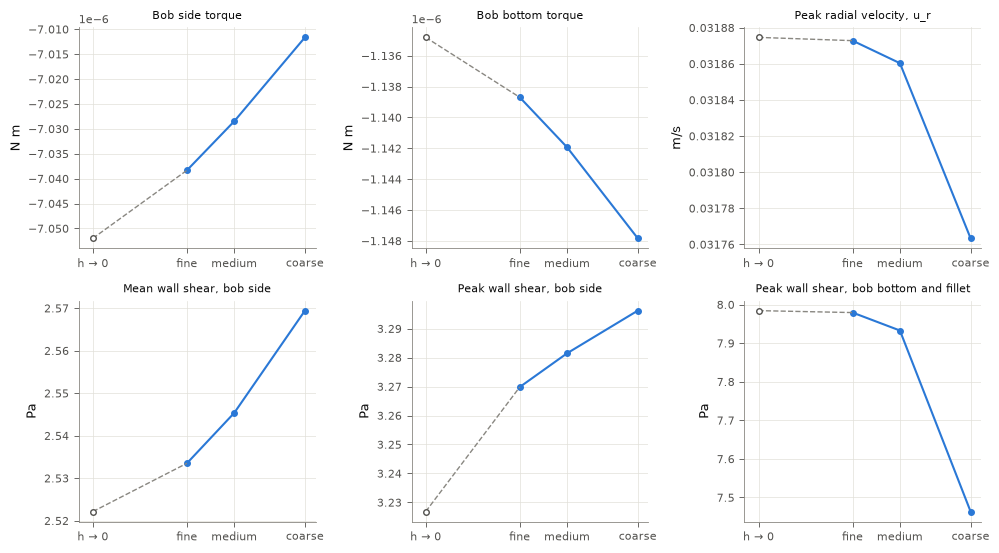

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.6))
ticks = [0, *h_rel[::-1]]
tick_labels = ["h → 0", *names[::-1]]
for ax, (key, (label, unit)) in zip(axes.ravel(), quantities.items()):
    v = np.array(values(key))
    ax.plot(h_rel, v, "o-", color=post.SERIES[0])
    r = results[key]
    if r is not None and not r["oscillatory"]:
        ax.plot([0, h_rel[-1]], [r["extrapolated"], v[-1]], "--", color=post.INK_MUTED, linewidth=1)
        ax.plot(0, r["extrapolated"], "o", markerfacecolor="white", color=post.INK_SECONDARY)
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(-0.15, h_rel[0] * 1.05)
    ax.set_title(label, fontsize=8)
    ax.set_ylabel(unit)
fig.tight_layout()

### Error against the extrapolated value

The error is plotted on log-log axes, so the slope of each line is the observed order of accuracy. The dotted lines
show slopes of 1 and 2. A line flatter than slope 1 has not reached the range where the error falls predictably.

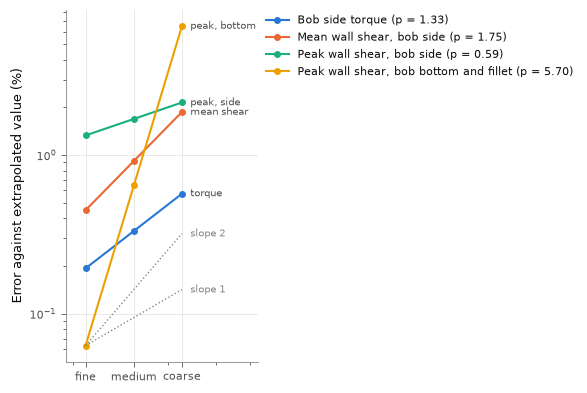

In [19]:
error_keys = ["T_side", "tau_mean", "tau_max", "tau_bottom_max"]
short = {"T_side": "torque", "tau_mean": "mean shear", "tau_max": "peak, side", "tau_bottom_max": "peak, bottom"}

fig, ax = plt.subplots(figsize=(6, 4))
fine_errors = []
for color, key in zip(post.SERIES, error_keys):
    r = results[key]
    if r is None:
        continue
    err = np.abs(np.array(values(key)) - r["extrapolated"]) / abs(r["extrapolated"]) * 100
    ok = err > 0
    ax.plot(h_rel[ok], err[ok], "o-", color=color, label=f"{quantities[key][0]} (p = {r['p']:.2f})")
    ax.annotate(short[key], (h_rel[ok][0], err[ok][0]), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=7, color=post.INK_SECONDARY)
    fine_errors.append(err[-1])

anchor = min(fine_errors)
x = np.array([1.0, h_rel[0]])
for order in (1, 2):
    ax.plot(x, anchor * x ** order, ":", color=post.INK_MUTED, linewidth=1)
    ax.annotate(f"slope {order}", (x[-1], anchor * x[-1] ** order), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=7, color=post.INK_MUTED)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(h_rel[::-1])
ax.set_xticklabels(names[::-1])
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlim(0.85, h_rel[0] * 1.9)
ax.set_ylabel("Error against extrapolated value (%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.tight_layout()

### Profiles

Radial velocity up the middle of the gap shows whether the vortices are in the same place on every mesh. The wall
shear profiles show where the peak is and whether its position and value move with refinement. The side and
the bottom (with the fillet) are plotted separately, so you can see which surface holds the highest shear.

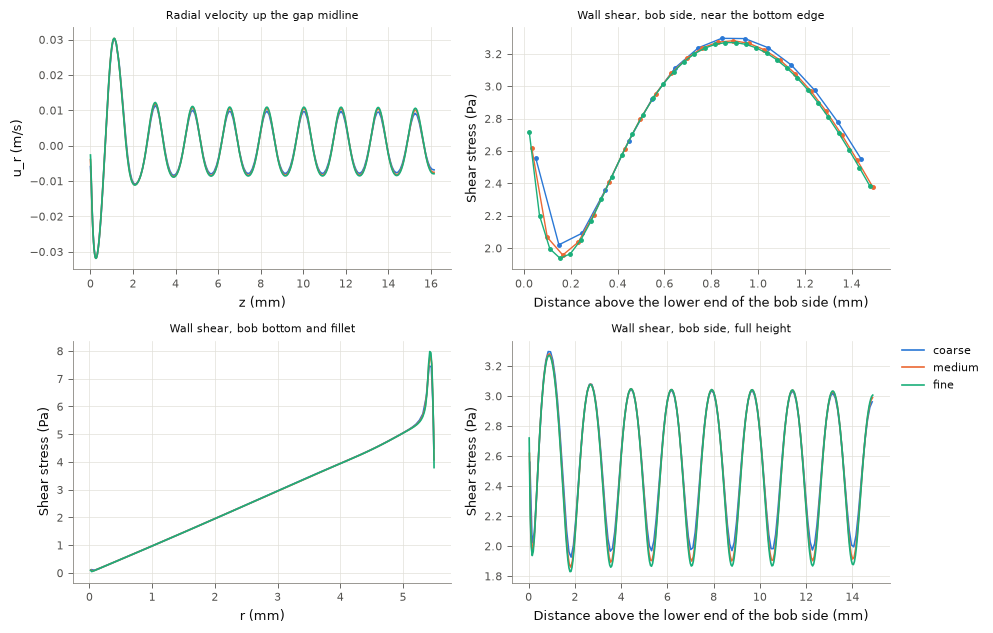

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))
ax_ur, ax_near, ax_bottom, ax_full = axes.ravel()

for name in names:
    d, color = data[name], mesh_colors[name]
    ax_ur.plot(d["z_ur"] * 1e3, d["ur"], color=color, linewidth=1.2, label=name)

    order = np.argsort(d["z_side"])
    above = (d["z_side"][order] - d["z_side_min"]) * 1e3        # mm above the lower end of the bob side
    tau = d["tau_side"][order]
    ax_full.plot(above, tau, color=color, linewidth=1.2)
    near = above <= 1.5
    ax_near.plot(above[near], tau[near], "o-", color=color, markersize=2.5, linewidth=1)

    order = np.argsort(d["r_bottom"])
    ax_bottom.plot(d["r_bottom"][order] * 1e3, d["tau_bottom"][order], color=color, linewidth=1.2)

ax_ur.set_title("Radial velocity up the gap midline", fontsize=8)
ax_ur.set_xlabel("z (mm)")
ax_ur.set_ylabel("u_r (m/s)")
ax_near.set_title("Wall shear, bob side, near the bottom edge", fontsize=8)
ax_near.set_xlabel("Distance above the lower end of the bob side (mm)")
ax_near.set_ylabel("Shear stress (Pa)")
ax_bottom.set_title("Wall shear, bob bottom and fillet", fontsize=8)
ax_bottom.set_xlabel("r (mm)")
ax_bottom.set_ylabel("Shear stress (Pa)")
ax_full.set_title("Wall shear, bob side, full height", fontsize=8)
ax_full.set_xlabel("Distance above the lower end of the bob side (mm)")
ax_full.set_ylabel("Shear stress (Pa)")
ax_full.legend(names, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.tight_layout()

### Convergence of each run

The side torque during each run, as a difference from its final value. The medium and fine runs start from the
interpolated solution of the mesh before, so they start with a smaller difference than the coarse run.

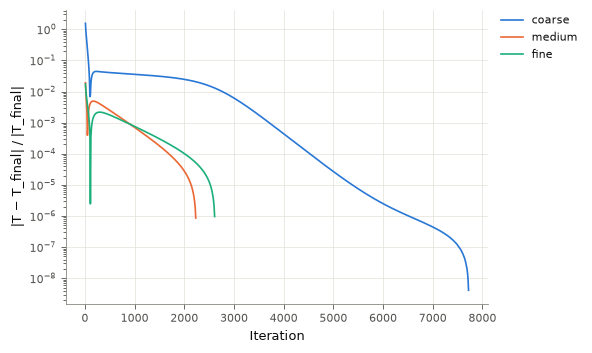

In [21]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for name in names:
    d = data[name]
    err = np.abs(d["T_hist"][:-1] - d["T_hist"][-1]) / abs(d["T_hist"][-1])
    ax.semilogy(d["t_hist"][:-1], np.maximum(err, 1e-12), color=mesh_colors[name], linewidth=1.2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("|T − T_final| / |T_final|")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.tight_layout()